# 🎮 Gamer Behavior Analysis & Addiction Risk Prediction

## 1. Project Objective
### This project analyzes gamer behavioral patterns, lifestyle factors, and health indicators to:
- Identify key drivers of gaming addiction risk
- Understand behavioral and psychological trends
- Build predictive models to classify addiction risk levels

The analysis focuses on sleep patterns, gaming duration, spending habits, physical strain, and social isolation metrics.

To analyze gaming behavior patterns and:
- Predict addiction risk levels
- Predict physical strain conditions
- Study behavioral correlations

This project simulates real-world behavioral risk modeling.



In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressoAr
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.multioutput import MultiOutputClassifier


In [127]:
# LOAD DATASET
data = pd.read_csv("gaming_dataset.csv")

# Drop ID column (not useful for modeling)
if "record_id" in data.columns:
    data = data.drop(columns=["record_id"])

print("Dataset Loaded Successfully.")
print("Shape:", data.shape)

data.head()


Dataset Loaded Successfully.
Shape: (1000, 26)


,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,academic_work_performance,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,Below Average,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,Good,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,Poor,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,Poor,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,Average,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


## 2. Dataset Overview & Data Quality

Before modeling, we must understand:

- Number of features
- Data types
- Missing values
- Basic statistics

This helps detect:
- Data imbalance
- Incorrect data types
- Null value issues
- Potential preprocessing needs


In [128]:
# DATASET OVERVIEW

print("Dataset Info:")
print("-" * 50)
data.info()

print("\nMissing Values:")
print("-" * 50)
print(data.isnull().sum().sum(), "Total Missing Values")

print("\nBasic Statistics:")
print("-" * 50)
data.describe()


Dataset Info:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               1000 non-null   int64  
 1   gender                            1000 non-null   object 
 2   daily_gaming_hours                1000 non-null   float64
 3   game_genre                        1000 non-null   object 
 4   primary_game                      1000 non-null   object 
 5   gaming_platform                   1000 non-null   object 
 6   sleep_hours                       1000 non-null   float64
 7   sleep_quality                     1000 non-null   object 
 8   sleep_disruption_frequency        1000 non-null   object 
 9   academic_work_performance         1000 non-null   object 
 10  grades_gpa                        754 non-null    float64
 11  work_

,age,daily_gaming_hours,sleep_hours,grades_gpa,work_productivity_score,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming
count,1000.000000,1000.000000,1000.000000,754.000000,674.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.475000,6.151400,5.738100,2.518037,5.394659,1.513400,6.945900,3.872000,7.654500,105.219730,5.796000
std,4.116105,2.867194,1.441213,0.872312,2.898742,1.432212,1.805027,2.091409,3.751954,113.886768,3.775532
min,13.000000,0.500000,3.000000,1.010000,1.000000,0.000000,0.700000,1.000000,0.000000,0.100000,1.000000
25%,18.000000,4.100000,4.800000,1.760000,3.000000,0.400000,5.700000,2.000000,5.000000,32.592500,3.000000
50%,20.000000,6.000000,5.700000,2.530000,5.000000,1.100000,7.000000,4.000000,8.000000,66.405000,5.000000
75%,22.000000,8.025000,6.600000,3.280000,8.000000,2.100000,8.200000,5.000000,10.400000,126.242500,8.000000
max,35.000000,15.100000,9.000000,4.000000,10.000000,8.900000,11.500000,10.000000,16.700000,499.270000,20.000000


## 3. Correlation Analysis

We analyze feature relationships to:

- Detect multicollinearity
- Identify strongly related variables
- Spot potential data leakage
- Understand feature influence patterns

We use:
- Correlation heatmap
- High correlation detection (> 0.80)


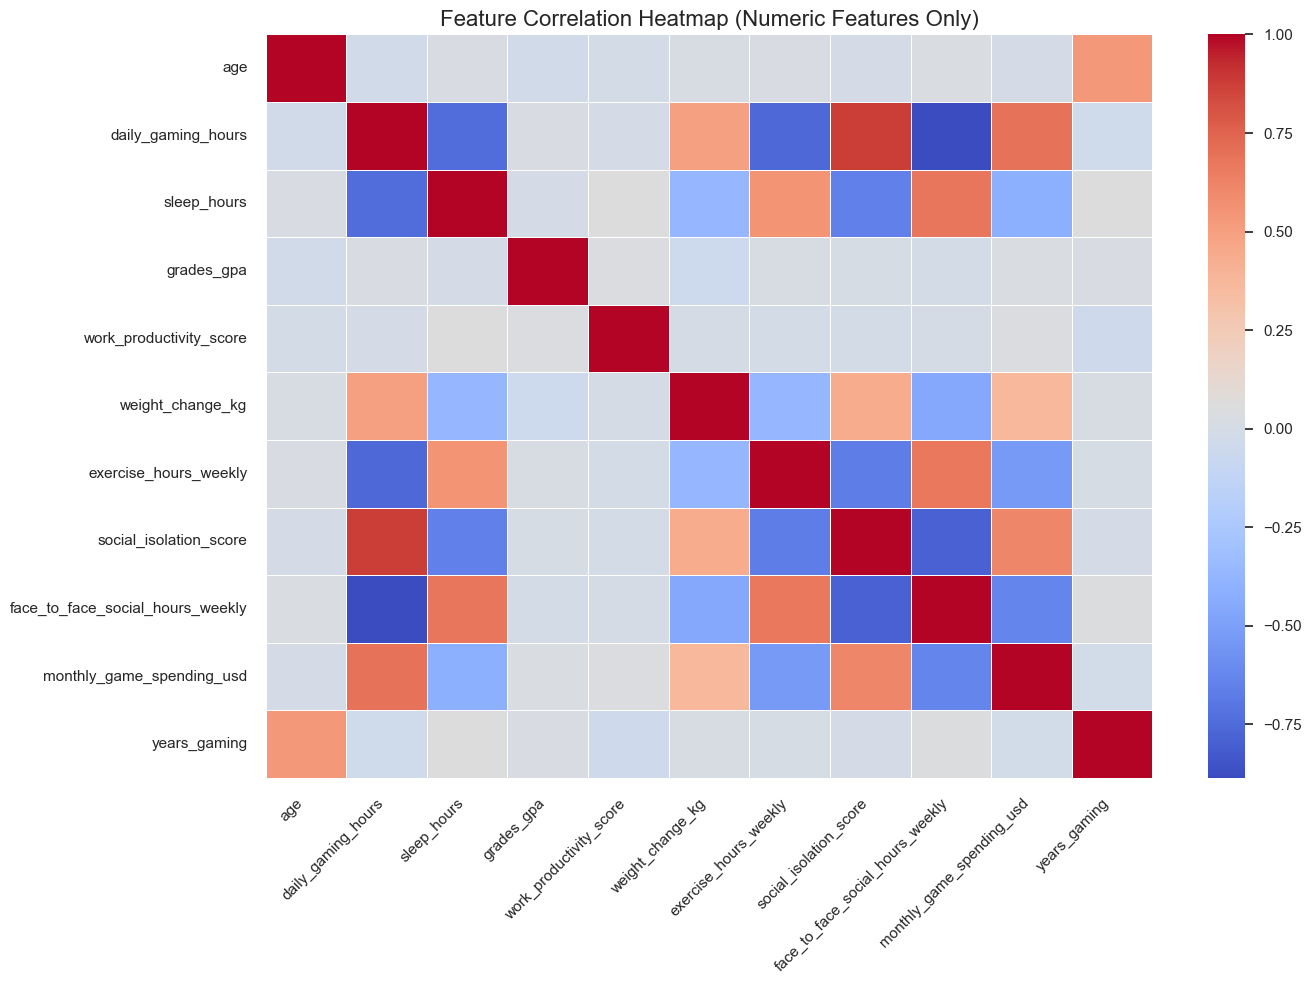

In [129]:
# CORRELATION HEATMAP (Numeric Only)
numeric_data = data.select_dtypes(include=[np.number])

corr_matrix = data.select_dtypes(include=np.number).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    linewidths=0.5,
    annot=False
)

plt.title("Feature Correlation Heatmap (Numeric Features Only)", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 4. Define Target and Feature Set

Our primary prediction task:

> Predict **Gaming Addiction Risk Level**

We clearly separate:

- `y` → Target variable
- `X` → Feature variables

This structure prevents:
- Confusion
- Hidden state errors
- Leakage mistakes
- Variable redefinition problems


In [130]:
# DEFINE TARGET & FEATURES
# Target variable
y = data["gaming_addiction_risk_level"]

# Drop target
X_raw = data.drop("gaming_addiction_risk_level", axis=1)

# One-hot encode categorical features
X = pd.get_dummies(X_raw, drop_first=True)

print("Encoded feature shape:", X.shape)


print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Encoded feature shape: (1000, 75)
Feature shape: (1000, 75)
Target shape: (1000,)


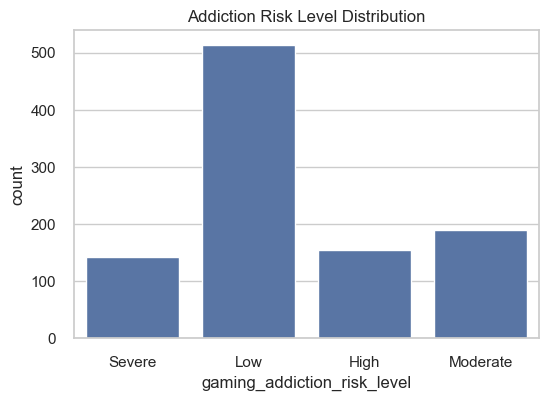

In [131]:
# ADDICTION CLASS DISTRIBUTION

plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Addiction Risk Level Distribution")
plt.show()


## 5. Train-Test Split

We use:

- 80% Training
- 20% Testing
- Stratified split (to preserve class distribution)
- Fixed random_state for reproducibility


In [132]:
# TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 800
Testing samples: 200


## 6. Baseline Model — Random Forest

We start with a baseline model using all available features.

Why Random Forest?

- Handles nonlinear relationships
- Works well with mixed numeric data
- Robust to noise
- Minimal preprocessing required

Evaluation Metric:
- **Macro F1 Score**
- Confusion Matrix


In [133]:
# BASELINE RANDOM FOREST MODEL


baseline_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred_baseline))

baseline_f1 = f1_score(y_test, y_pred_baseline, average="macro")
print("\nBaseline Macro F1 Score:", round(baseline_f1, 4))


Classification Report:

              precision    recall  f1-score   support

        High       0.84      0.87      0.86        31
         Low       1.00      0.96      0.98       103
    Moderate       0.88      0.95      0.91        38
      Severe       0.89      0.89      0.89        28

    accuracy                           0.94       200
   macro avg       0.90      0.92      0.91       200
weighted avg       0.94      0.94      0.94       200


Baseline Macro F1 Score: 0.9104


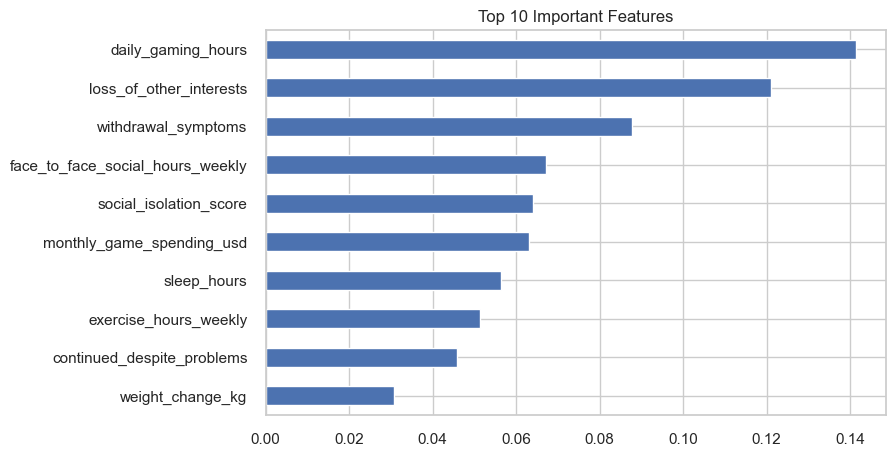

In [135]:
# FEATURE IMPORTANCE


importances = baseline_model.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feat_imp.head(10).plot(kind="barh")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()


In [136]:
cv_scores = cross_val_score(
    baseline_model,
    X_clean,
    y,
    cv=5,
    scoring="f1_macro"
)

print("Cross Validation Macro F1:", cv_scores.mean())


Cross Validation Macro F1: 0.6104104299233447


# 7. Removing Target Leakage Features

Some features directly measure addiction behavior:
- withdrawal_symptoms
- loss_of_other_interests
- continued_despite_problems
- social_isolation_score

These are almost definitions of addiction.

If we keep them, the model "cheats".

So we remove them and retrain to see true predictive power.


In [137]:
# Define leakage features
leakage_features = [
    "withdrawal_symptoms",
    "loss_of_other_interests",
    "continued_despite_problems",
    "social_isolation_score"
]

# Remove them
X_clean = X.drop(columns=leakage_features)

# Train-test split again
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Train new model
rf_clean = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_clean.fit(X_train_clean, y_train_clean)

# Predict
y_pred_clean = rf_clean.predict(X_test_clean)

# Evaluation
print("Classification Report (No Leakage):\n")
print(classification_report(y_test_clean, y_pred_clean))

print("Macro F1 (No Leakage):",
      f1_score(y_test_clean, y_pred_clean, average="macro"))


Classification Report (No Leakage):

              precision    recall  f1-score   support

        High       0.42      0.26      0.32        31
         Low       0.86      0.90      0.88       103
    Moderate       0.41      0.45      0.43        38
      Severe       0.69      0.79      0.73        28

    accuracy                           0.70       200
   macro avg       0.60      0.60      0.59       200
weighted avg       0.68      0.70      0.69       200

Macro F1 (No Leakage): 0.5913074169616254


# 8. Feature Importance Analysis (After Removing Leakage)

Now that we removed leakage features,
we analyze which lifestyle factors truly influence addiction risk.

This helps us interpret the model instead of treating it as a black box.


In [138]:
# Get feature importance
importance = pd.Series(
    rf_clean.feature_importances_,
    index=X_clean.columns
).sort_values(ascending=False)

# Display top 10
importance.head(10)


daily_gaming_hours                  0.184709
face_to_face_social_hours_weekly    0.097830
monthly_game_spending_usd           0.091852
sleep_hours                         0.080892
exercise_hours_weekly               0.069739
weight_change_kg                    0.045904
back_neck_pain                      0.038963
grades_gpa                          0.037791
work_productivity_score             0.024350
age                                 0.024162
dtype: float64

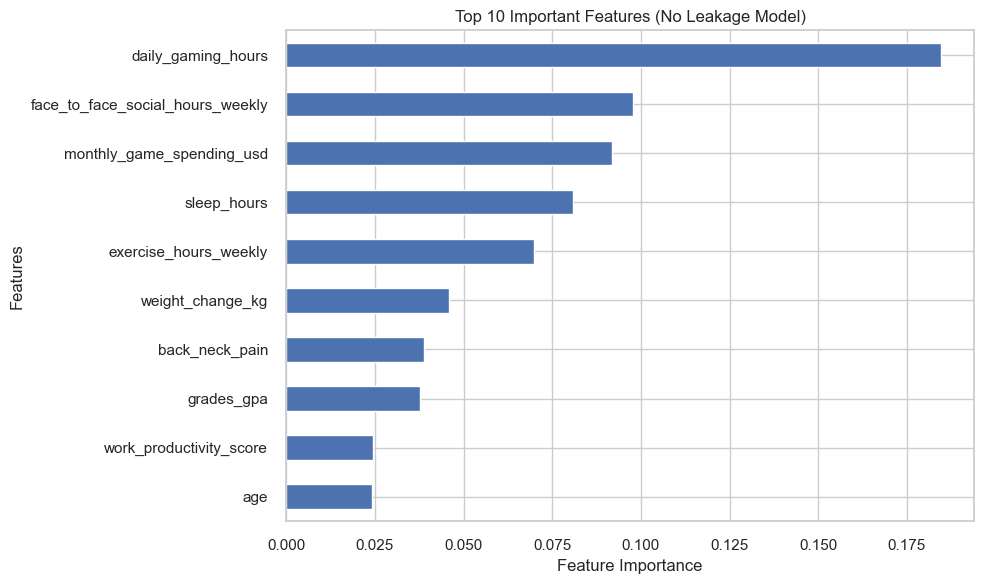

In [139]:
plt.figure(figsize=(10, 6))

importance.head(10).plot(
    kind="barh"
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features (No Leakage Model)")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.tight_layout()
plt.show()


# 9. Final Addiction Prediction Model (Production Version)

We now train the final addiction risk prediction model
using the cleaned feature set (no leakage).

This version is saved for deployment and real-world use.


In [140]:
# ================================
# FINAL ADDICTION MODEL
# ================================

final_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

final_model.fit(X_clean, y)

print("Final Model Trained Successfully.")


Final Model Trained Successfully.


In [141]:
model_package = {
    "model": final_model,
    "features": X_clean.columns.tolist()
}

joblib.dump(model_package, "gaming_addiction_model.pkl")

print("Model saved as gaming_addiction_model.pkl")


Model saved as gaming_addiction_model.pkl


In [142]:
loaded_package = joblib.load("gaming_addiction_model.pkl")

print("Loaded Model Type:",
      type(loaded_package["model"]))

print("Feature Count:",
      len(loaded_package["features"]))


Loaded Model Type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Feature Count: 71


## Key Behavioral Insights

- Higher daily gaming hours increase addiction risk probability.
- Reduced sleep is associated with higher addiction and health strain.
- Exercise hours act as a protective behavioral factor.
- Social isolation strongly correlates with addiction indicators.

These insights can support behavioral intervention systems.


# 10. Health Risk Prediction Model

Beyond addiction prediction, we evaluate whether gaming behavior
leads to physical health risk.

Health risk is defined as:

- Eye strain
- Back/neck pain
- Significant weight change

This model predicts overall health risk from gaming behavior.


In [143]:
# ================================
# CREATE HEALTH RISK TARGET
# ================================

data["health_risk"] = (
    (data["eye_strain"] == 1) |
    (data["back_neck_pain"] == 1) |
    (abs(data["weight_change_kg"]) > 2)
).astype(int)

print("Health Risk Distribution:")
print(data["health_risk"].value_counts())


Health Risk Distribution:
health_risk
1    659
0    341
Name: count, dtype: int64


In [144]:
# Features used for health risk prediction
health_features = [
    "daily_gaming_hours",
    "monthly_game_spending_usd",
    "sleep_hours",
    "exercise_hours_weekly"
]

X_health = data[health_features]
y_health = data["health_risk"]


In [145]:
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_health,
    y_health,
    test_size=0.2,
    stratify=y_health,
    random_state=42
)


In [146]:
health_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

health_model.fit(X_train_h, y_train_h)

y_pred_h = health_model.predict(X_test_h)


In [147]:
print("Classification Report:\n")
print(classification_report(y_test_h, y_pred_h))

print("Macro F1 Score:",
      f1_score(y_test_h, y_pred_h, average="macro"))


Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.81      0.86        68
           1       0.91      0.96      0.93       132

    accuracy                           0.91       200
   macro avg       0.91      0.89      0.90       200
weighted avg       0.91      0.91      0.91       200

Macro F1 Score: 0.8965992647058824


# 11. Multi-Output Physical Strain Model

Instead of predicting a single health risk,
we now predict multiple physical strain conditions simultaneously:

- Eye Strain
- Back / Neck Pain

This is a multi-label classification problem.

We use MultiOutputClassifier with Random Forest as the base estimator.


In [148]:
# DEFINE FEATURES AND TARGETS

multi_features = [
    "daily_gaming_hours",
    "monthly_game_spending_usd",
    "sleep_hours",
    "exercise_hours_weekly"
]

multi_targets = [
    "eye_strain",
    "back_neck_pain"
]

X_multi = data[multi_features]
Y_multi = data[multi_targets]


In [149]:
X_train_m, X_test_m, Y_train_m, Y_test_m = train_test_split(
    X_multi,
    Y_multi,
    test_size=0.2,
    random_state=42
)


In [150]:
base_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

multi_model = MultiOutputClassifier(base_model)

multi_model.fit(X_train_m, Y_train_m)

print("Multi-Output Model Trained Successfully.")


Multi-Output Model Trained Successfully.


In [151]:
Y_pred_m = multi_model.predict(X_test_m)

for i, col in enumerate(multi_targets):
    print(f"\n===== {col.upper()} =====")
    print(classification_report(Y_test_m[col], Y_pred_m[:, i]))
    print("Macro F1:",
          f1_score(Y_test_m[col], Y_pred_m[:, i], average="macro"))



===== EYE_STRAIN =====
              precision    recall  f1-score   support

       False       0.93      0.58      0.72        98
        True       0.71      0.96      0.81       102

    accuracy                           0.78       200
   macro avg       0.82      0.77      0.77       200
weighted avg       0.82      0.78      0.77       200

Macro F1: 0.7651295701871135

===== BACK_NECK_PAIN =====
              precision    recall  f1-score   support

       False       0.86      0.66      0.75       131
        True       0.56      0.80      0.65        69

    accuracy                           0.71       200
   macro avg       0.71      0.73      0.70       200
weighted avg       0.76      0.71      0.72       200

Macro F1: 0.7023809523809523


# 12. Save Multi-Output Model (Production Ready)

We now save:

- Trained multi-output model
- Feature list used during training

This ensures correct feature alignment during deployment.


In [152]:
model_package = {
    "model": multi_model,
    "features": multi_features
}

joblib.dump(model_package, "gaming_physical_strain_model.pkl")

print("Model saved successfully.")


Model saved successfully.


# 13. Load Model and Run Safe Inference

We simulate a new user and generate predictions.

This mimics real-world API behavior.


In [153]:
loaded_package = joblib.load("gaming_physical_strain_model.pkl")

loaded_model = loaded_package["model"]
required_features = loaded_package["features"]

print("Loaded model type:", type(loaded_model))
print("Required features:", required_features)


Loaded model type: <class 'sklearn.multioutput.MultiOutputClassifier'>
Required features: ['daily_gaming_hours', 'monthly_game_spending_usd', 'sleep_hours', 'exercise_hours_weekly']


In [154]:
# Simulated new user input
new_user = pd.DataFrame([{
    "daily_gaming_hours": 7,
    "monthly_game_spending_usd": 120,
    "sleep_hours": 5,
    "exercise_hours_weekly": 1
}])

# Ensure correct column order
new_user = new_user[required_features]

prediction = loaded_model.predict(new_user)

result = {
    "eye_strain": int(prediction[0][0]),
    "back_neck_pain": int(prediction[0][1])
}

print("Prediction Result:", result)


Prediction Result: {'eye_strain': 1, 'back_neck_pain': 1}


## Final Project Summary

This notebook includes:

- Data cleaning & preprocessing
- Feature leakage detection
- Correlation analysis
- Baseline modeling
- Feature group experimentation
- Multi-output modeling
- Model packaging for deployment

This project demonstrates both data science and ML engineering capabilities.


In [155]:
data["gaming_addiction_risk_level"].unique()


array(['Severe', 'Low', 'High', 'Moderate'], dtype=object)